In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KEY = ['x', 'y', 'z', 'time_idx']
VEL = ['u', 'v', 'w']
GRAD = ['dudx', 'dudy', 'dudz', 'dvdx', 'dvdy', 'dvdz', 'dwdx', 'dwdy', 'dwdz']
MOMENTS = ['Mx_roll', 'My_pitch', 'Mz_yaw']
AXES = ['Roll', 'Pitch', 'Yaw']

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot

wind_path   = '../wind_aligned_at_CoM.csv'
moment_path = '../vlm_body_moments.csv'

wind = pd.read_csv(wind_path)
mom  = pd.read_csv(moment_path)

for d in (wind, mom):
    d['x'] = d['x'].round(6)          # kill the float noise
    d['y'] = d['y'].round(6)
    d['z'] = d['z'].astype(float).round(6)
    d['time_idx'] = d['time_idx'].astype(int)

df = wind.merge(mom, on=KEY)

# Full model = velocity + gradient at the CG
input_cols = VEL + GRAD
labels = ['u', 'v', 'w',
          '∂u/∂x', '∂u/∂y', '∂u/∂z',
          '∂v/∂x', '∂v/∂y', '∂v/∂z',
          '∂w/∂x', '∂w/∂y', '∂w/∂z']

X = df[input_cols].values
Y = df[MOMENTS].values
print("X shape:", X.shape, " Y shape:", Y.shape)

G_T, *_ = np.linalg.lstsq(X, Y, rcond=None)   # solve M = X @ G_T
G = G_T.T                                       # (3 x n_inputs)
Yhat = X @ G_T


X shape: (192000, 12)  Y shape: (192000, 3)


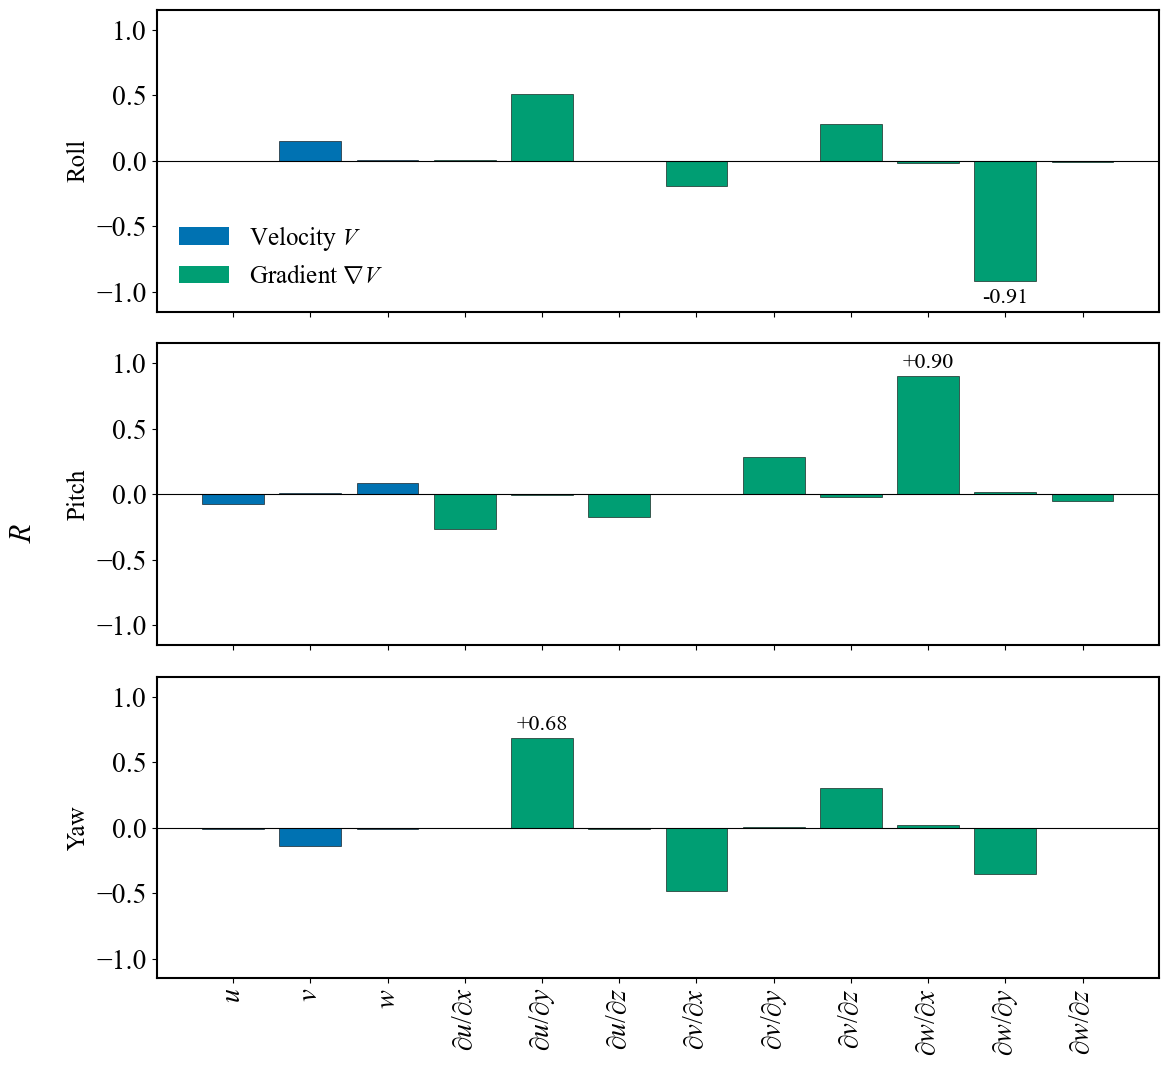

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "axes.linewidth": 1.5,
    "axes.grid": False,
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
})

# correlation of each input with each moment
corr = np.array([[np.corrcoef(X[:, j], Y[:, ai])[0, 1]
                  for j in range(len(input_cols))]
                 for ai in range(3)])

vel_c, grad_c = '#0072B2', '#009E73'          # velocity / gradient
bar_colors = [vel_c]*3 + [grad_c]*9

# math-form x labels (order must match input_cols)
labels = [r'$u$', r'$v$', r'$w$',
          r'$\partial u/\partial x$', r'$\partial u/\partial y$', r'$\partial u/\partial z$',
          r'$\partial v/\partial x$', r'$\partial v/\partial y$', r'$\partial v/\partial z$',
          r'$\partial w/\partial x$', r'$\partial w/\partial y$', r'$\partial w/\partial z$']

panel_labels = ['Roll', 'Pitch', 'Yaw']

fig, axs = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for ai in range(3):
    axs[ai].bar(range(12), corr[ai], color=bar_colors, edgecolor='k', linewidth=0.4)
    axs[ai].axhline(0, color='k', lw=0.8)
    axs[ai].set_ylim(-1.15, 1.15)                       # headroom for annotations
    axs[ai].set_yticks([-1, -0.5, 0, 0.5, 1])
    axs[ai].set_ylabel(panel_labels[ai])                # which moment

    # annotate the dominant driver
    j = np.argmax(np.abs(corr[ai]))
    axs[ai].annotate(f'{corr[ai, j]:+.2f}',
                     xy=(j, corr[ai, j]),
                     xytext=(0, 6 if corr[ai, j] >= 0 else -16),
                     textcoords='offset points', ha='center', fontsize=16)

axs[-1].set_xticks(range(12))
axs[-1].set_xticklabels(labels, rotation=90)

axs[0].legend(handles=[Patch(facecolor=vel_c, label=r'Velocity $V$'),
                       Patch(facecolor=grad_c, label=r'Gradient $\nabla V$')],
              loc='lower left', fontsize=18, frameon=False)

fig.supylabel(r'$R$', fontsize=22)

plt.tight_layout()
plt.show()



In [4]:
# 50/50 split: fit on one half, test on the half it never saw
rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
h   = len(X) // 2
tr, te = idx[:h], idx[h:]

# fit on TRAIN half only
G_T_tr, *_ = np.linalg.lstsq(X[tr], Y[tr], rcond=None)

print(f"{'Axis':6} {'Train':>8} {'Test':>8} {'Gap':>8}")
for ai, name in enumerate(AXES):
    r_tr = r_squared(Y[tr, ai], X[tr] @ G_T_tr[:, ai])
    r_te = r_squared(Y[te, ai], X[te] @ G_T_tr[:, ai])
    print(f"{name:6} {r_tr:8.3f} {r_te:8.3f} {r_tr - r_te:8.3f}")

print(f"\nn_train = {len(tr):,}   n_test = {len(te):,}")

Axis      Train     Test      Gap
Roll      0.847    0.850   -0.004
Pitch     0.828    0.827    0.000
Yaw       0.603    0.597    0.006

n_train = 96,000   n_test = 96,000


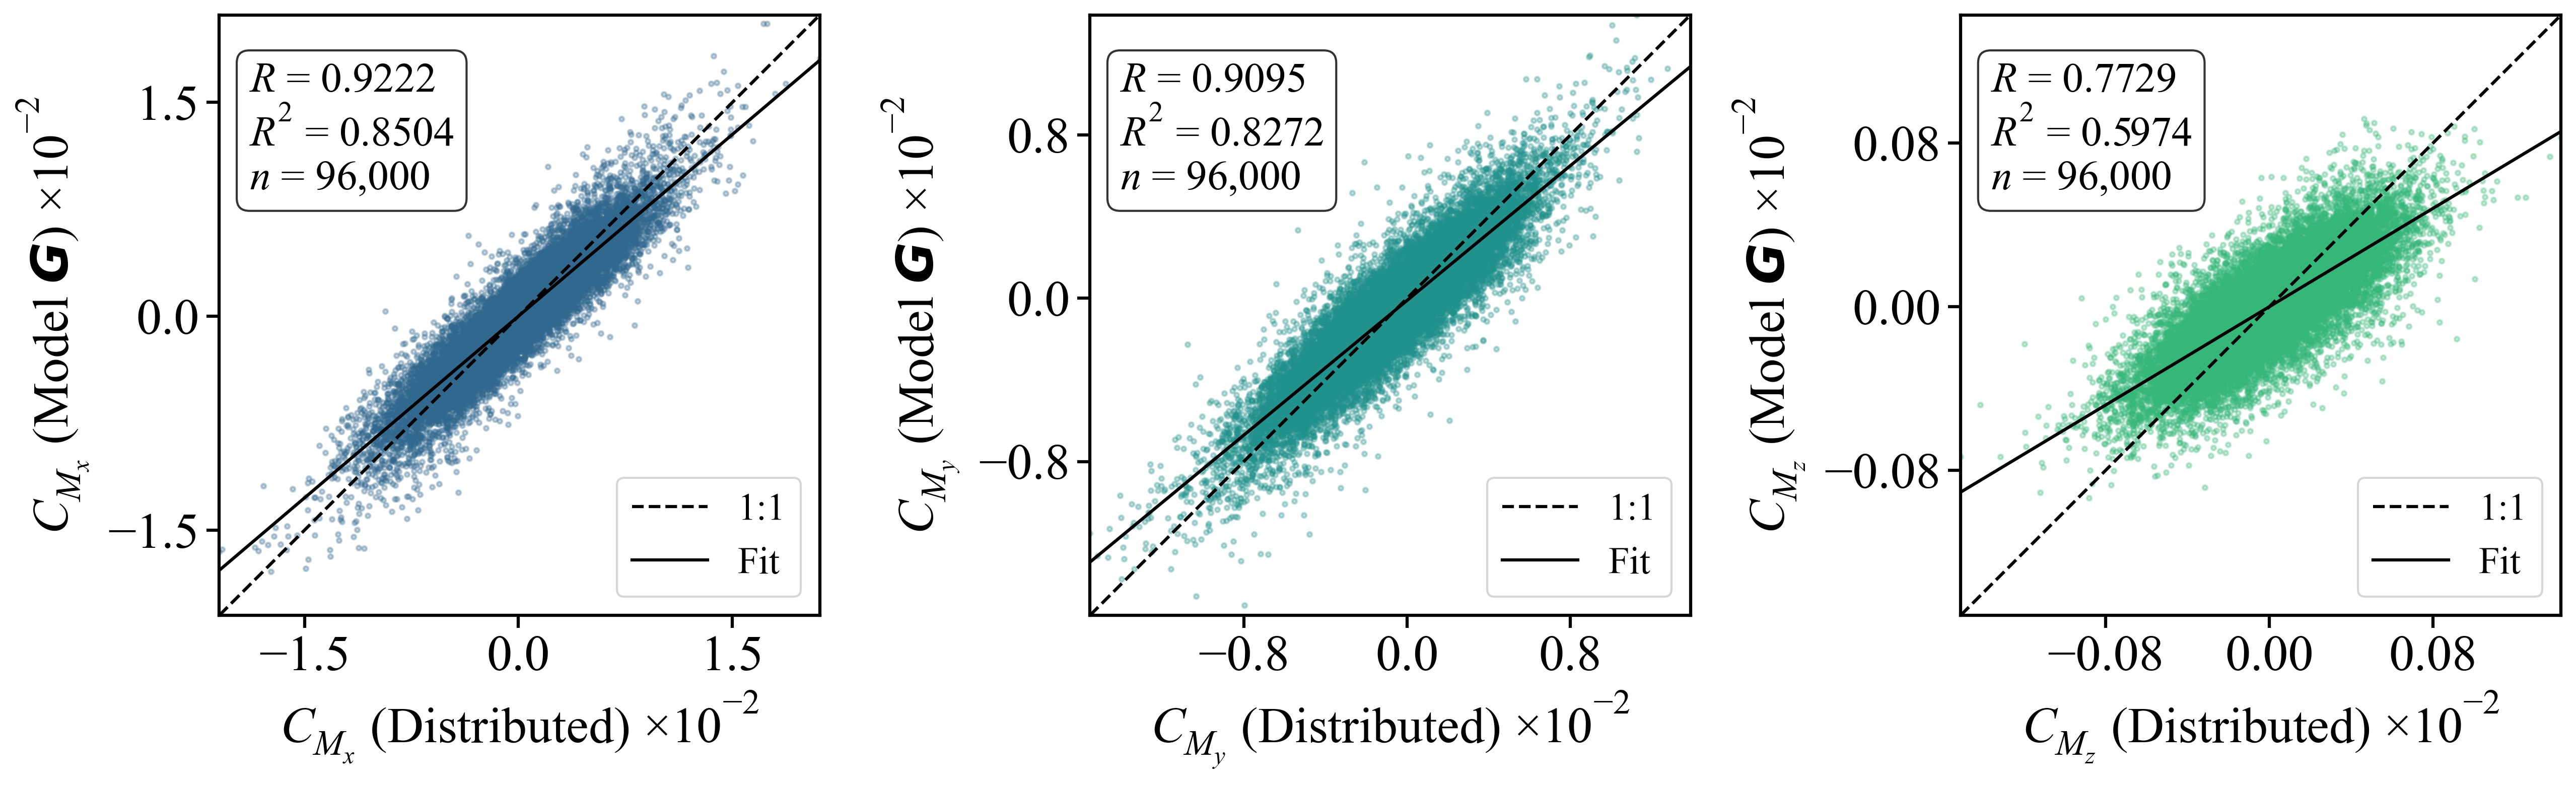

In [7]:
# ---- G prediction vs distributed, on the HELD-OUT test half ----
rho, rpm, R_tip = 1.225, 570, 2.809

n = rpm / 60.0
D = 2 * R_tip
CM_denom = rho * n**2 * D**5

plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman"],
    "font.size": 24, "axes.labelsize": 24,
    "xtick.labelsize": 24, "ytick.labelsize": 24,
    "axes.linewidth": 1.5, "axes.grid": False,
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
})

colors = ['#31688E', '#21918C', '#35B779']
labels = [r'$C_{M_x}$', r'$C_{M_y}$', r'$C_{M_z}$']
scale  = 100

Y_pred_te = X[te] @ G_T_tr          # G's prediction on unseen data

fig, axs = plt.subplots(1, 3, figsize=(20, 6), dpi=300)
for ai, (ax, label, color) in enumerate(zip(axs, labels, colors)):
    y_true = Y[te, ai]      / CM_denom * scale     # distributed (C_M)
    y_pred = Y_pred_te[:, ai] / CM_denom * scale   # G-predicted (C_M)

    r2 = r_squared(y_true, y_pred)
    r  = np.corrcoef(y_true, y_pred)[0, 1]

    ax.scatter(y_true, y_pred, s=5, alpha=0.3, color=color)

    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='1:1')
    slope, intercept = np.polyfit(y_true, y_pred, 1)
    ax.plot(np.array(lims), slope*np.array(lims) + intercept, '-k', lw=1.5, label='Fit')

    ax.set_xlabel(f'{label} (Distributed)' + r' $\times 10^{-2}$')
    ax.set_ylabel(f'{label} (Model $\\boldsymbol{{G}}$)' + r' $\times 10^{-2}$', labelpad=8)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', length=6, width=1.5)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    ax.text(0.05, 0.92, f'$R$ = {r:.4f}\n$R^2$ = {r2:.4f}\n$n$ = {len(y_true):,}',
            transform=ax.transAxes, fontsize=20, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(loc='lower right', fontsize=18, frameon=True)

plt.subplots_adjust(wspace=0.45)
plt.show()

In [8]:
# ---- Monte Carlo over many random 50/50 splits ----
# Guards against the result being an artifact of one lucky shuffle.
n_trials = 100
test_r2 = np.zeros((n_trials, 3))
gaps    = np.zeros((n_trials, 3))

for t in range(n_trials):
    rng = np.random.default_rng(t)              # a different seed each trial
    idx = rng.permutation(len(X))
    h = len(X) // 2
    tr, te = idx[:h], idx[h:]
    G_t, *_ = np.linalg.lstsq(X[tr], Y[tr], rcond=None)
    for ai in range(3):
        r_tr = r_squared(Y[tr, ai], X[tr] @ G_t[:, ai])
        r_te = r_squared(Y[te, ai], X[te] @ G_t[:, ai])
        test_r2[t, ai] = r_te
        gaps[t, ai]    = r_tr - r_te

print(f"Over {n_trials} random 50/50 splits:\n")
print(f"{'Axis':6} {'Test R² mean':>13} {'std':>8} {'min':>8} {'max':>8} "
      f"{'Gap mean':>10} {'Gap std':>9}")
for ai, name in enumerate(AXES):
    print(f"{name:6} {test_r2[:,ai].mean():13.4f} {test_r2[:,ai].std():8.4f} "
          f"{test_r2[:,ai].min():8.4f} {test_r2[:,ai].max():8.4f} "
          f"{gaps[:,ai].mean():10.4f} {gaps[:,ai].std():9.4f}")

Over 100 random 50/50 splits:

Axis    Test R² mean      std      min      max   Gap mean   Gap std
Roll          0.8486   0.0012   0.8457   0.8512    -0.0002    0.0025
Pitch         0.8271   0.0015   0.8226   0.8297     0.0006    0.0030
Yaw           0.5999   0.0028   0.5941   0.6077     0.0006    0.0057
